# *path_finder*: A multi-criterion retrosynthesis planning tool with experimental validation

**Authors:** Yara Chahda, Ines Ouchen Laksiri  
**Affiliation:** École Polytechnique Fédérale de Lausanne (EPFL)  
**Date:** May 2026  

---

## 1. Introduction

### 1.1 Research topic

The design of a chemical synthesis is one of the central intellectual exercises of organic chemistry. For a given target molecule, dozens of disconnections are conceivable, each one leading to a different set of starting materials, a different number of steps, and a different overall economic and environmental cost. The systematic enumeration of these possibilities — known as *retrosynthetic analysis* since the formalisation by E. J. Corey — has been progressively automated over the last decade by Monte Carlo tree-search (MCTS) algorithms trained on millions of literature reactions. Tools such as AiZynthFinder (Genheden et al., 2020) and ASKCOS (Coley et al., 2019) can now propose plausible synthetic trees for arbitrary small molecules in a matter of minutes. The question is no longer *whether* a retrosynthesis can be generated, but *which one* among the many proposals should actually be carried out at the bench.

### 1.2 Niche

In the specific niche of natural-product and drug synthesis, the answer to that question depends heavily on context. A medicinal chemist optimising a lead compound during early-stage discovery cares mostly about step count and time. A process chemist scaling a clinical candidate cares about cumulative yield, atom economy, E-factor, and the safety profile of the reagents and solvents. Educational settings, where students are asked to compare published routes to a given alkaloid, demand transparency about *why* one route ranks above another. Existing open-source retrosynthesis tools deliver synthetic trees but stop short of providing this comparative, criterion-aware layer, and they almost never expose validated experimental yields alongside their machine-generated predictions.

### 1.3 Problem

There is therefore a gap between the raw output of a retrosynthesis engine (a list of trees) and the actual decision a chemist needs to make (which tree to pursue, and on what grounds). Three sub-problems compose this gap. First, results produced by tree-search models are *purely predicted*: they carry no experimental yield, no validated conditions, and no guarantee that the proposed step has ever been reported in the literature. Second, when a route is taken from a curated literature dataset, it must still be scored on multiple, sometimes-conflicting criteria — and the relative weight of those criteria is user-dependent. Third, the user must be able to *understand* the ranking, otherwise the tool degenerates into a black box and the chemist is back to picking a route by intuition.

### 1.4 Solution

The `path_finder` package addresses these three sub-problems jointly. It couples an AiZynthFinder MCTS search to a curated dataset of published synthesis routes (*Chemistry by Design*), to a flat database of individual literature reactions for step-by-step validation, and to Rxn-INSIGHT (Wigh et al., 2024) for the prediction of plausible conditions when no literature record is available. Each candidate route is then scored on five chemical criteria (step count, cumulative yield, atom economy, E-factor, and a reagent-and-solvent safety score derived from a toxicity database), the user selects three of them in priority order, and the package returns a ranking using an inverse-square weighting scheme (≈73 % / 18 % / 9 %). Routes are partitioned into three explicit categories — `dataset`, `validated`, and `predicted` — so the experimental status of every step is always visible. The whole pipeline is exposed through a Streamlit interface that renders interactive reaction schemes, side-by-side comparisons, a dataset explorer, and a downloadable PDF report. The remainder of this document describes how the package is structured, what it produces on representative test cases, and what its current limitations are.

## 2. Materials and methods

### 2.1 Software architecture

The package is organised as five Python modules, each with a well-defined responsibility, and a Streamlit front-end that consumes them. `route_engine.py` is the chemistry backend: it loads datasets, runs AiZynthFinder, queries Rxn-INSIGHT, computes per-criterion scores, and produces the final ranking. `molecule_rendering.py` wraps RDKit Cairo so that every molecule in the interface is drawn as a high-resolution PNG that remains sharp on HiDPI displays. `app_layout.py` collects every user-visible string in an English and a French dictionary, together with the colour palette used by Matplotlib charts. `report_builder.py` generates a multi-page A4 PDF route report using PIL. `app.py` is the Streamlit entry point and `app_utensils.py` contains the UI helper functions; it imports the four modules above and contains only presentation logic. This separation means that the scientific core (`route_engine.py`) can be imported and tested independently of any user interface, which is a deliberate choice — the same backend can be reused in a Jupyter notebook, in a CLI tool, or in a future REST API without modification.

### 2.2 Datasets used

Three datasets are consumed by the engine. The *main curated dataset* (`reaction_dataset.json`) contains complete, multi-step published routes towards drug-relevant targets, with experimentally reported yields and full reaction conditions. The *generic reactions dataset* (`generic_reactions.json`) is a flat collection of individual literature reactions whose role is to validate, step by step, the routes proposed by the tree-search engine. The *toxicity dataset* (`toxicity_dataset.json`) provides a hazard score in [0, 1] for each indexed compound and is used by the safety criterion. A fourth, optional resource — the Rxn-INSIGHT USPTO Parquet file — supplies suggested solvents, catalysts, and reagents for steps that are not found in either dataset.

### 2.3 Route generation and classification

The engine begins by canonicalising the target SMILES with RDKit and launching an AiZynthFinder Monte Carlo tree search using the USPTO expansion and filter policies and the ZINC stock of purchasable building blocks. By default twenty-five routes are retrieved from the tree-search algorithm, though only the top three in each category are displayed to the user. This deliberate oversampling ensures that the validation step, which cross-checks each AiZynthFinder proposal against the generic reactions database, has a sufficiently large pool to work with, thereby increasing the likelihood of finding routes with experimental precedent. Each raw AiZynthFinder route is then converted from its native tree representation to a linear, forward-ordered list of steps (starting materials → target).

Each route is subsequently routed to one of three categories. *Dataset* routes are those whose final product canonicalises to the target SMILES and whose entire sequence is taken verbatim from the main curated dataset. *Validated* routes are AiZynthFinder proposals in which at least one step matches a reaction in the generic dataset, either by an exact (reactants, product) tuple match or by a product-only fallback. *Predicted* routes are AiZynthFinder proposals with no step found in any dataset; these are annotated with Rxn-INSIGHT-suggested conditions and their yield is set to `None`. This three-way partition is fundamental to the rest of the pipeline — it determines which scoring rules apply and which visual cues are shown to the user. 

### 2.4 Scoring criteria

Five criteria are implemented and registered in a central `CRITERIA_REGISTRY` dictionary so that they can be added or removed without modifying the ranking loop. The *steps* criterion maps a route of $n$ steps to $1/n$, rewarding shorter sequences. The *yield* criterion is the cumulative product of all reported step yields expressed as a fraction in $[0, 1]$; missing yields are treated as $1.0$ (neutral) to avoid penalising steps with incomplete literature data, and for predicted routes the criterion is excluded outright. *Atom economy* is computed step by step as $\text{MW}(\text{product}) / \sum \text{MW}(\text{reactants})$, capped at unity, then averaged over the route. The *E-factor* score is $1 / (1 + \text{E-factor})$, where the E-factor is the ratio of kilograms of waste to kilograms of product calculated from the reactant and product molecular weights and the step yield. The *safety* criterion is $1 - \overline{h}$, where $\overline{h}$ is the mean hazard score of every reactant and every solvent appearing in the route; compounds absent from the toxicity dataset are assigned a neutral hazard of $0.5$.

### 2.5 Weighting and ranking

The user selects three criteria in decreasing order of importance. Weights are assigned using an inverse-square priority scheme: the first-priority criterion receives a raw weight of 1/(1²) = 1.0, the second receives 1/(2²) = 0.25, and the third receives 1/(3²) ≈ 0.111. These raw weights are then normalized to sum to unity, yielding final weights of approximately 73%, 18%, and 9% respectively. This scheme ensures that the highest-priority criterion dominates the ranking while the remaining two retain sufficient weight to resolve ties between routes with similar scores on the first criterion.

Each route is assigned a single scalar score by computing the weighted sum of its raw criterion scores: $\text{score} = \sum_{i=1}^{3} w_i \times s_i$, where $w_i$ is the normalized weight of criterion $i$ and $s_i$ is the raw score for that criterion. For predicted routes, the yield criterion is automatically excluded from the sum and the remaining weights are renormalized so that these routes are not unfairly penalized for lacking experimental yield data. Routes are then sorted in descending order of their total score within each of the three categories (dataset, validated, predicted). The category structure itself is not collapsed into a single global ranking — this separation is deliberate. Merging a fully validated literature synthesis with a purely machine-predicted route into the same ordered list would obscure exactly the information that the user needs in order to assess the reliability of each result.

### 2.6 User interface

The Streamlit interface is organized into four principal tabs, each serving a distinct purpose in the route-discovery workflow. 

The *Route Search* tab accepts a target molecule either by selection from the curated dataset or by manual SMILES entry, prompts the user to rank three scoring criteria in order of priority, and allows adjustment of the number of AiZynthFinder routes to explore and the number of top-ranked routes to display per category. Once the search completes, results are presented as expandable route cards partitioned into the three validation categories (dataset, validated, predicted). Each card displays a summary of key metrics (total score, step count, bottleneck yield, average yield), a detailed per-criterion score breakdown table, an interactive reaction scheme where clicking any arrow reveals full step details and copyable SMILES strings, a collapsible list of required starting materials and reagents, and a button to download a PDF report of the complete route.

The *Analysis* tab facilitates direct comparison of any user-selected subset of routes through both a tabular view — which juxtaposes scores across all five criteria side by side — and a grouped horizontal bar chart that visualizes the raw scores for the three active criteria, making trade-offs immediately visible. The *Dataset Explorer* tab provides unrestricted access to the underlying curated reaction dataset: users can filter by target molecule, browse a sortable summary table showing cumulative yields and step counts for all routes, and expand any route to view its complete step-by-step sequence with full molecular structures, conditions, and reported yields. The *Help* tab documents the algorithmic methodology, the dataset structure, and the validation workflow in plain language accessible to non-specialist users.

Throughout the interface, all visual elements — molecule structure images, reaction scheme diagrams, and statistical charts — are rendered at two to eight times their nominal display resolution using RDKit Cairo and Matplotlib at high DPI, then downsampled via Lanczos filtering in the browser or during PNG encoding. This ensures that carbon–carbon bond lines remain visually sharp on high-pixel-density Retina and HiDPI displays without appearing aliased or blurred.

### 2.7 Reproducibility


The package requires Python 3.10 and depends on several key libraries: RDKit (2023.9.6) for molecular structure handling and canonicalization, AiZynthFinder (4.4.1) for the MCTS retrosynthesis search, pandas (2.3.3) for dataset manipulation, Streamlit (1.56.0) for the web interface, Matplotlib (3.10.8) for chart generation, Pillow (12.2.0) for image processing in the PDF builder, and optionally rxn-insight (0.1.2) for reaction classification and condition prediction. A complete environment specification is provided in the repository as `path_finder-env.yml`, which can be instantiated with `conda env create -f path_finder-env.yml` followed by `conda activate path_finder-env.yml`.

The AiZynthFinder policy network files (trained on the USPTO dataset) and stock file (ZINC purchasable building blocks) must be downloaded separately and their paths specified in the `config.yml` configuration file, as these exceed GitHub's file-size limits. The optional Rxn-INSIGHT USPTO reaction database is similarly provided as an external download in Parquet format compressed with gzip. Once the environment is activated and the data files are in place, the application launches with the single command `path-finder` after running `path-finder-setup` from the package root directory. A typical retrosynthesis search for a drug-sized target (15–30 heavy atoms) completes in one to two minutes on a standard laptop equipped with a modern multi-core processor.

The following cells demonstrate the core functions of the `path_finder` package independently of the Streamlit interface. All functions are importable directly from the package modules, confirming that the scientific backend is fully decoupled from the user interface.

**Demonstration 1 — SMILES canonicalisation.** The `to_canonical()` function wraps RDKit's canonicalisation routine and handles edge cases such as list inputs, invalid SMILES, and salt mixtures. It is called systematically before any dataset lookup or scoring operation to ensure that structurally identical molecules represented by different SMILES strings are always recognised as equivalent.

In [2]:
from path_finder.route_engine import to_canonical

smiles = "OC1C=C[C@@]23c4cc(OC)ccc4CN(C)C[C@@H]2[C@@H]1O3"
print(f"Input:     {smiles}")
print(f"Canonical: {to_canonical(smiles)}")

Input:     OC1C=C[C@@]23c4cc(OC)ccc4CN(C)C[C@@H]2[C@@H]1O3
Canonical: COc1ccc2c(c1)[C@@]13C=CC(O)[C@@H](O1)[C@H]3CN(C)C2


**Demonstration 2 — Dataset loading.** The `load_reaction_dataset()` function parses the main curated JSON dataset and builds three secondary indices (by product, by reactant, and by route) in a single pass. The indices enable O(1) lookups during route matching and are constructed automatically on load.

In [1]:
from path_finder.route_engine import load_reaction_dataset

ds = load_reaction_dataset('../data/reaction_dataset.json')
print(f"Reactions: {len(ds['all'])}")
print(f"Routes:    {len(ds['by_route'])}")
print(f"Targets:   {list(ds['by_route'].keys())[:5]}")

[dataset] 483 reactions loaded
[dataset] 31 distinct routes indexed
Reactions: 483
Routes:    31
Targets:   ['aggarwal_2010', 'aube_2000', 'bach_2012', 'borger_2012', 'brown_2022']


**Demonstration 3 — Yield metrics.** Two yield metrics are computed from the step data: the cumulative yield (product of all reported step yields) and the bottleneck yield (minimum step yield). Both functions gracefully handle missing yield data by excluding `None` values rather than treating them as zero.

In [3]:
from path_finder.route_engine import cumulative_yield, bottleneck_yield

# Example with 3 steps
steps = [
    {"yield_percent": 85.0},
    {"yield_percent": 72.0},
    {"yield_percent": 91.0},
]
print(f"Cumulative yield: {cumulative_yield(steps)*100:.1f}%")
print(f"Bottleneck yield: {bottleneck_yield(steps):.1f}%")

Cumulative yield: 55.7%
Bottleneck yield: 72.0%


**Demonstration 4 — Molecule rendering.** The `mol_png()` function renders any valid SMILES string as a high-resolution PNG using RDKit Cairo at 8× the display size, then returns the raw bytes. The image below confirms that the rendering pipeline is functional and produces crisp bond lines suitable for both the Streamlit interface and the PDF report builder.

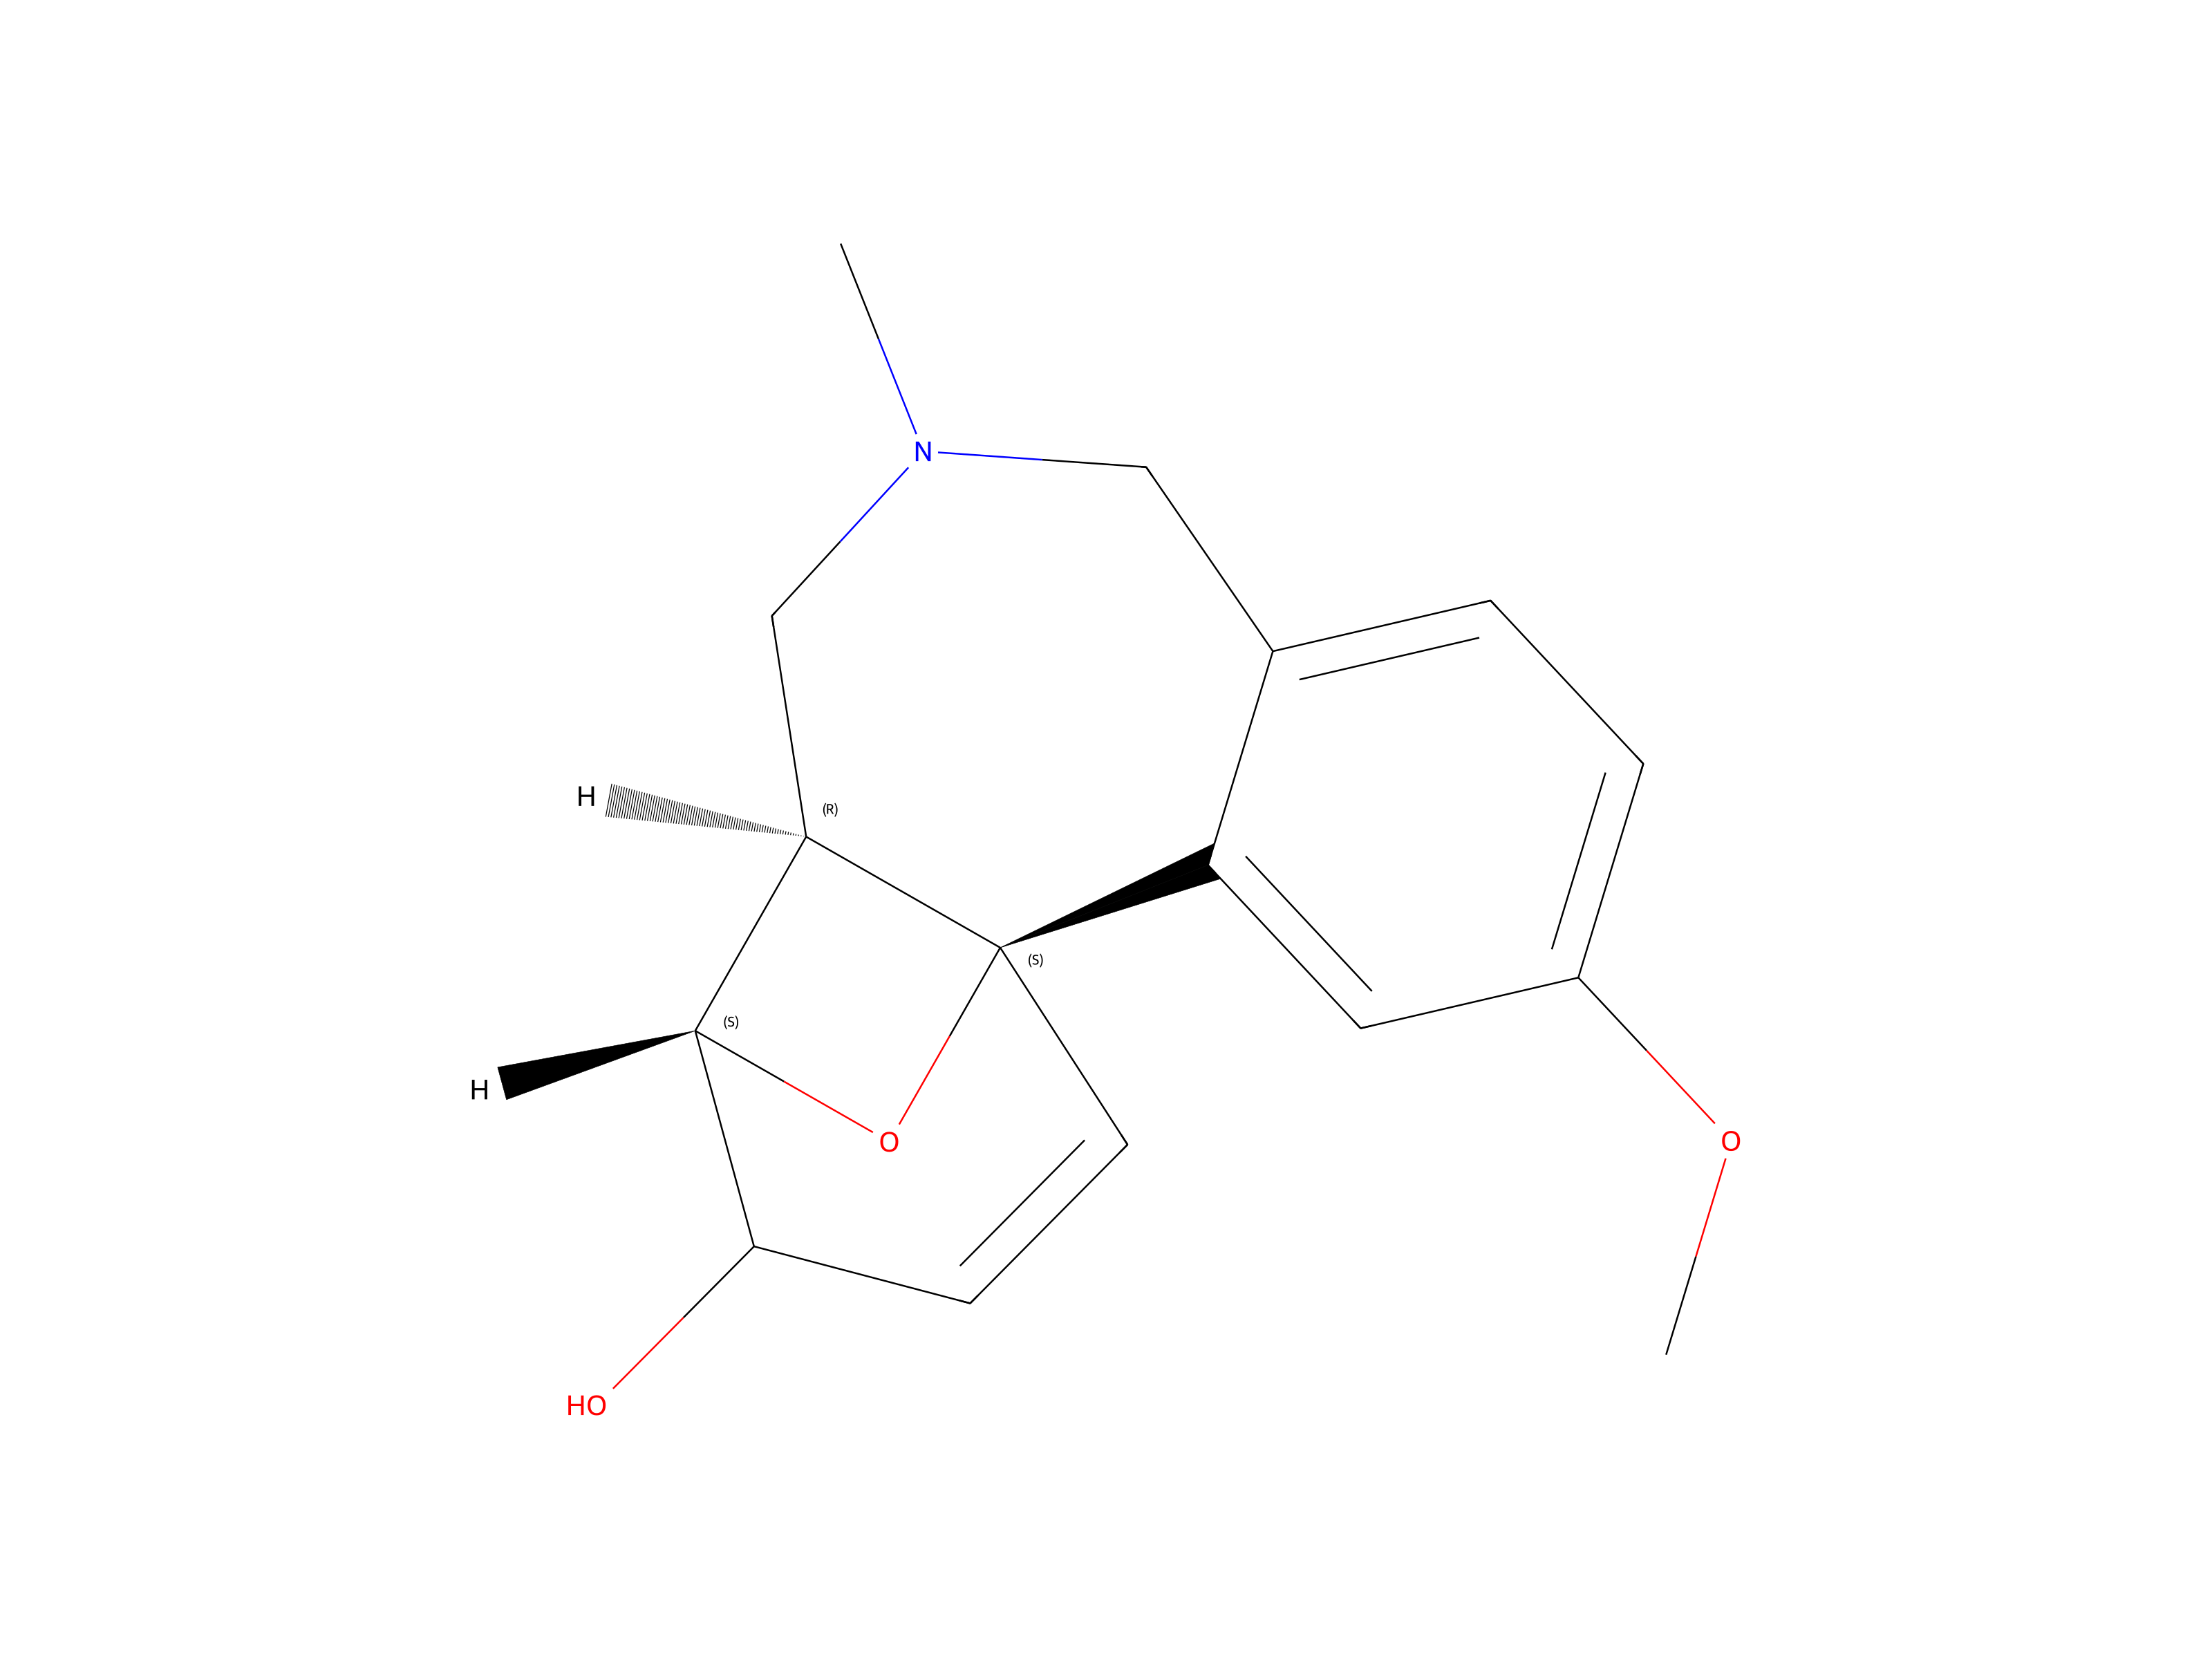

In [1]:
from path_finder.molecule_rendering import mol_png
from IPython.display import Image

galanthamine = "OC1C=C[C@@]23c4cc(OC)ccc4CN(C)C[C@@H]2[C@@H]1O3"
png = mol_png(galanthamine, 400, 300)
Image(data=png)

## 3. Results

### 3.1 What the package delivers

For an arbitrary target molecule, the package returns three independently ranked lists of synthesis routes together with the full metadata required to interpret them. Dataset routes are accompanied by their original literature yields and conditions and serve as a ground truth against which the machine-generated proposals can be compared. Validated routes report, on a step-by-step basis, which steps have a literature precedent and which were taken from Rxn-INSIGHT predictions, so the user can see at a glance how much of the route is experimentally supported. Predicted routes are clearly flagged with an orange colour scheme and their yield column is annotated as *excluded from scoring*. The total score, the per-criterion raw score, the weight, and the resulting contribution to the total are displayed for every route, together with a short natural-language justification that names the two top-weighted criteria and the values they reached.

![Interface](screenshots/interface.png)

### 3.2 Behaviour on representative targets

When the package is run on galanthamine, an alkaloid for which several historical syntheses are present in the main dataset, the *Dataset* section returns the full literature routes with their reported step yields. The *Validated* section returns AiZynthFinder proposals whose disconnections coincide partially with the generic dataset — typically the late-stage steps, which are documented in the patent literature — while the early-stage construction of the bridged tetracyclic core is annotated by Rxn-INSIGHT predictions. The *Predicted* section is populated only when AiZynthFinder explores routes that share no step with any dataset, which is common for targets at the boundary of the training distribution. For morphine, a similarly well-documented target, the same three-way structure is reproduced, and the cumulative-yield ranking inside the *Dataset* section recovers the routes generally cited in the literature as the most efficient.

![Reaction Scheme](screenshots/reaction_scheme.png)

### 3.3 Effect of criterion ordering

Because the weighting scheme assigns approximately three quarters of the total score to the first criterion, the choice of priority order has a strong, visible effect on the ranking. Setting *Steps* as the highest-priority criterion promotes short telescoped sequences even when their cumulative yield is modest. Setting *Yield* first restores classical step-economy thinking and tends to bring forward routes whose worst step still exceeds 60 – 70 %. Setting *Safety* first pushes routes that avoid chlorinated solvents and reactive metallic reagents to the top, sometimes at the cost of two additional steps. The Analysis tab makes this trade-off explicit by showing the raw scores for every criterion side by side, so the user can verify that no criterion was sacrificed in an unacceptable way.

![Analysis](screenshots/analysis.png)

### 3.4 Quality of the scheme rendering

Each interactive reaction scheme renders molecules at 8× the display size with RDKit Cairo, embeds them as base-64 PNG data URIs in a self-contained HTML document, and downsamples to 2× via Lanczos filtering in the browser. The result is a scheme that remains visually sharp at any zoom level, and where any arrow can be clicked to open a detail panel showing the full reactant and product structures, the conditions, the source (dataset, generic dataset, or Rxn-INSIGHT), and a clipboard-copyable SMILES for each species. Purification or isolation steps — identified either by an explicit keyword in the reaction type field or by reactant–product canonical identity — are displayed with a dashed brown arrow and a dedicated badge, preserving the integrity of the recorded synthetic sequence.

![Dataset Explorer](screenshots/data.png)

### 3.5 Exported deliverables

Every route can be exported as an A4 PDF report. The first page contains the route name, the validation status, the total score, the metric cards, the score-breakdown table, and a grid of the starting-material structures. The subsequent pages render up to three reaction steps each, with thick bond lines, full SMILES labels for every species, and a coloured header band that switches from navy to orange depending on the data source. Full SMILES strings are wrapped across multiple lines rather than truncated so that a chemist reading the PDF away from the application still has access to every machine-readable structure.

**Demonstration 5 — Full retrosynthesis search.** The cell below calls `find_best_routes()`, the main entry point of the package. It requires the AiZynthFinder model files and the Rxn-INSIGHT database to be present locally. 

The search typically takes 1–2 minutes on a standard laptop.

In [ ]:
from path_finder.route_engine import find_best_routes

results = find_best_routes(
    target_smiles        = "OC1C=C[C@@]23c4cc(OC)ccc4CN(C)C[C@@H]2[C@@H]1O3",
    criteria_priority    = ["yield", "steps", "toxicity"],
    dataset_path         = "../data/reaction_dataset.json",
    toxicity_path        = "../data/toxicity_dataset.json",
    config_path          = "../data/config.yml",
    generic_dataset_path = "../data/generic_reactions.json",
    rxninsight_db_path   = "../data/uspto_rxn_insight.gzip",
    top_n                = 3,
    n_aiz_routes         = 25,
    )
print(f"Dataset routes:   {len(results['dataset'])}")
print(f"Validated routes: {len(results['validated'])}")
print(f"Predicted routes: {len(results['predicted'])}")

## 4. Discussion

### 4.1 What the package contributes

The main contribution of `path_finder` is not the retrosynthesis itself — AiZynthFinder already does that, and very well — but the *contextualisation* layer that sits on top of it. By cross-referencing every machine-generated step against a curated literature dataset and a generic reactions database, the tool gives each route a verifiable experimental pedigree, or, when no pedigree exists, an explicit *predicted* tag. This addresses a fundamental gap in most academic retrosynthesis interfaces: they present model output as if it were equivalent to a published synthesis, with no distinction between a step that has been executed hundreds of times in the literature and one that has never been attempted. The chemist using `path_finder` can immediately see, on a step-by-step basis, where literature support ends and machine prediction begins. For a validated route, the interface distinguishes steps sourced from the generic reactions database (which carry real experimental conditions and yields) from steps annotated by Rxn-INSIGHT (which carry only predicted conditions). This granularity is essential for experimental planning: a chemist attempting a seven-step synthesis needs to know which three steps are reliable and which four require optimization.

The second contribution is the explicit, configurable, and explainable scoring scheme. The five criteria implemented here — step count, cumulative yield, atom economy, E-factor, and reagent safety — cover the dimensions that practising chemists actually argue about when comparing synthetic routes. The inverse-square weighting scheme (73% / 18% / 9%) forces the user to commit to a priority order rather than entering arbitrary numerical weights, which are notoriously difficult to choose and often reflect unconscious biases. For instance, setting *yield* as the first priority implicitly declares that a four-step route with 80% cumulative yield is preferable to a two-step route with 50% cumulative yield, even though the latter is shorter. The per-criterion breakdown table makes this trade-off explicit by showing the raw score, the weight, and the contribution of each criterion to the total. The *why ranked* paragraph complements the numerical breakdown by stating, in plain language, which two top-weighted criteria drove the ranking and what values they achieved. This combination — quantitative transparency paired with qualitative explanation — turns the score from a single opaque number into a justifiable decision that can be defended in a group meeting or a teaching context.

### 4.2 Limitations

However, several limitations should be acknowledged, as they constrain the scope of applicability and point toward future improvements. The five chemical criteria, while standard in green-chemistry discourse, do not exhaust the considerations a chemist actually faces when selecting a route for execution. Reagent and starting-material procurement cost, which can vary by two orders of magnitude depending on supplier and scale, is not currently modelled. The availability of specialised equipment — such as high-pressure hydrogenation apparatus, cryogenic cooling, or microwave reactors — is similarly absent, though it often determines whether a particular step is feasible in a given laboratory. Patent constraints, which can render an otherwise-excellent route legally inaccessible for commercial production, are not checked. These omissions mean that the package is best suited for academic route exploration and teaching rather than for industrial process selection.

The safety criterion in particular is only as good as the toxicity dataset behind it. Compounds absent from that dataset are assigned a neutral hazard score of 0.5, which means that an unknown but highly toxic reagent — such as a newly reported organometallic catalyst or an obscure solvent — can pass through the filter undetected and appear in a high-ranked route. A conservative alternative would be to assign unknown compounds a pessimistic hazard of 0.8, thereby penalising routes that rely on poorly characterised materials, but this risks unfairly downranking innovative chemistry. The current neutral-default policy reflects a deliberate choice to avoid penalising routes for data incompleteness, but users should be aware that the safety score is only reliable for well-studied commodity reagents and solvents.

The Rxn-INSIGHT condition predictions are statistical: they reflect the most frequently co-occurring solvents, catalysts, and temperatures in the USPTO patent corpus for reactions that resemble the target transformation according to a Morgan-fingerprint similarity metric. These predictions should be treated as suggestions for initial screening rather than as validated recipes. A predicted condition set might propose palladium acetate in toluene at 110°C because that combination appears often in the training data, but it offers no guarantee that the specific substrate in question will react under those conditions. In practice, a chemist would use the Rxn-INSIGHT suggestion as a starting point and then optimize the reaction empirically.

As already mentioned, the validation pipeline matches generic-dataset reactions either by exact reactant–product tuple or by product alone when no exact match is found. The product-only fallback introduces a risk: it can in principle return a reaction with the correct product SMILES but different precursors, thereby marking a step as *validated* even though the actual disconnection was not found in the literature. For example, if the generic dataset contains a Suzuki coupling that produces a biaryl from bromobenzene and a boronic acid, and AiZynthFinder proposes the same biaryl from an iodobenzene precursor, the product-only match would incorrectly validate the step. This risk is mitigated by the fact that the exact-match level is attempted first, so product-only fallback only occurs when no exact match exists, but the possibility of false positives remains. A more robust solution would add a third matching level based on structural similarity: compute the Tanimoto coefficient between the AiZ-proposed reactants and the generic-dataset reactants, and accept a match only if the coefficient exceeds a threshold such as 0.7. This would catch cases where the precursors are closely related but not identical.

Finally, the cumulative-yield score treats missing yields as neutral 1.0 values. This design choice was made to avoid penalising historical literature routes, which often report conditions and products but omit isolated yields. However, it creates an asymmetry: a route with one unreported step and four steps reported at 80% each will score higher (cumulative yield = 0.8⁴ = 0.41) than a route with all five steps honestly reported at 80% (cumulative yield = 0.8⁵ = 0.33), even though they may represent equivalent synthetic efficiency. A more conservative approach would treat missing yields as 0.5 (average) rather than 1.0 (perfect), but this would unfairly punish older literature. The current policy favours transparency over conservatism, and users comparing routes should be aware that a higher yield score may partly reflect data availability rather than intrinsic synthetic efficiency.

### 4.3 Possible extensions

Several extensions follow naturally from the current architecture and would address some of the limitations identified above. The `CRITERIA_REGISTRY` is intentionally designed as an open dictionary structure, so additional criteria can be added by defining a new scoring function and registering it without modifying the ranking loop in `route_engine.rank_weighted()`. Candidate extensions include process mass intensity (total mass of all reagents and solvents per unit mass of product, a metric commonly used in pharmaceutical manufacturing), solvent environmental and health safety scoring according to the CHEM21 guide (which assigns red/yellow/green ratings to common organic solvents based on toxicity, flammability, and persistence), or a reagent-cost criterion that queries real-time pricing from a chemical-supplier API such as Sigma-Aldrich or Fluorochem and penalises routes that rely on expensive building blocks. Each of these would require a corresponding dataset or API integration but could slot directly into the existing weighting framework.

The validation pipeline could be strengthened by implementing the structural-similarity matching level described in Section 4.2. Concretely, this would involve computing ECFP4 (Morgan radius-2) fingerprints for both the AiZ-proposed reactants and the generic-dataset reactants, calculating the Tanimoto coefficient, and accepting a validation match if the coefficient exceeds 0.7 even when the exact reactant tuple does not match. This would reduce false negatives (where a closely related literature precedent exists but is not recognised due to minor structural variation) without significantly increasing false positives, since a Tanimoto threshold of 0.7 is conservative enough to exclude unrelated transformations.

A REST API wrapper around `route_engine.find_best_routes()` would enable integration into electronic lab-notebook systems such as Benchling, LabArchives, or institutional LIMS platforms. The API could accept a JSON payload containing the target SMILES, the three criteria, and the dataset paths, then return the ranked routes as a structured JSON response with embedded base64-encoded molecule images. This would allow chemists to query retrosynthesis predictions directly from within their existing workflow without launching a separate Streamlit interface.

Finally, an interactive mode in which the user accepts or rejects each disconnection during the MCTS search — essentially turning the tree exploration into a guided dialogue — would bring the tool closer to the way expert chemists actually reason about retrosynthesis. In this mode, AiZynthFinder would propose a disconnection, render the resulting precursors, and wait for user approval before expanding that branch further. This human-in-the-loop approach would allow chemists to encode tacit knowledge that is difficult to capture in a policy network, such as "avoid quaternary centres adjacent to strained rings" or "prefer electrophilic aromatic substitution over cross-coupling for electron-rich heterocycles". The technical implementation would require modifying the AiZynthFinder search loop to insert a callback after each expansion step, but the existing modular structure of the codebase makes this feasible.

### 4.4 Implementation challenges

Several technical challenges were encountered during development that merit documentation for future contributors. The most persistent issue was achieving acceptable image resolution for molecular structures across different display contexts. RDKit's default Cairo renderer produces vector-quality output at the drawing stage, but embedding these images in both the Streamlit interface and the PDF report required careful resolution management: structures that appeared sharp in the browser would become pixelated when zoomed in the PDF, while high-resolution assets would cause the Streamlit application to load slowly. The solution — rendering at four to eight times the nominal display size and applying Lanczos downsampling — was reached only after systematic experimentation with different DPI settings and resampling algorithms. PDF generation presented a related challenge: the reportlab library, which is commonly used for programmatic PDF creation in Python, does not expose sufficient control over font rendering and multi-line text wrapping for chemical structure labels, particularly for long SMILES strings that must be broken across lines without truncation. The final implementation uses PIL (Pillow) to draw every page element pixel by pixel, which sacrifices the compactness of a vector-based PDF but guarantees that what is rendered matches exactly what was intended, including thick bond lines and correctly wrapped SMILES labels.

A further challenge arose in the integration of the generic reactions dataset with the AiZynthFinder route validation pipeline. The SMILES canonicalisation step proved critical: AiZynthFinder and RDKit do not always produce identical canonical forms for the same molecule, particularly for stereochemical descriptors and aromatic systems. This caused false negatives in the step-matching logic, where a reaction present in the generic dataset would not be recognised as a match because the SMILES strings differed in notation despite representing the same structure. The solution was to apply `Chem.MolToSmiles(Chem.MolFromSmiles(smi))` systematically to every SMILES string at both indexing time and query time, ensuring that all comparisons operate on a canonical representation independent of the source.

The absence of a pre-existing curated dataset of literature synthesis routes posed a significant data-preparation burden. While several public reaction databases exist — Reaxys, SciFinder, and the USPTO patent corpus — none provide multi-step routes in a machine-readable format with standardised fields for target molecule, step number, reactants, products, conditions, and yields. The Chemistry by Design web interface provides human-readable route summaries but does not expose a structured API or bulk download. The main curated dataset used in this package was therefore assembled manually by extracting routes from the Chemistry by Design interface, converting structure images to SMILES using the SciLifeLab Image-to-SMILES tool and the Cheminfo SMILES generator, validating each entry with RDKit canonical parsing, and structuring the results as a JSON file with consistent field names. This process consumed a substantial portion of the project timeline and underscores a broader gap in the open chemical-informatics ecosystem: there is no widely adopted standard for representing multi-step synthesis routes in a machine-readable format, analogous to the role that SMILES plays for individual molecules or SMARTS for reaction transforms. Future work in this area would benefit from community adoption of a structured route-description language, possibly building on the Open Reaction Database (ORD) schema, which currently focuses on single-step reactions but could be extended to encode complete synthetic sequences.

Packaging the application for distribution via PyPI introduced an unexpected set of constraints. The AiZynthFinder policy network files and the Rxn-INSIGHT USPTO reaction database together exceed 500 MB, making them unsuitable for inclusion in a standard Python wheel. The solution was to bundle only the three lightweight JSON datasets within the package and to implement a first-run setup wizard (`path-finder-setup`) that programmatically invokes AiZynthFinder's own `download_public_data` utility to retrieve the model files automatically. This approach transfers the download burden from the package build process to the user's first run, while keeping the `pip install path-finder-retrosynthesis` command fast and dependency-light. A secondary challenge was that RDKit, a core dependency, is not available on PyPI and must be installed via conda, which required explicit documentation and a two-step installation procedure rather than the single `pip install` command that most Python users expect.

The internationalisation of the interface (English and French) required centralising every user-visible string in a single `app_layout.py` dictionary rather than embedding strings directly in the Streamlit code. While straightforward in principle, this constraint revealed numerous edge cases where strings were constructed programmatically — by concatenating labels, inserting numeric values, or formatting percentages — rather than retrieved as atomic entries. Each such case required refactoring to use Python's `str.format()` pattern with named placeholders, ensuring that translated strings could reorder tokens without breaking the surrounding logic.

## 5. Conclusion

`path_finder` packages an MCTS retrosynthesis engine, a curated dataset of literature routes, a generic-reaction database, a condition-prediction model, and a five-criterion scoring scheme into a single Streamlit application that is both directly usable at the bench and pedagogically transparent. The three-way partition of routes into *dataset*, *validated*, and *predicted* categories — together with the explicit per-criterion score breakdown and the natural-language justification — addresses the central problem identified in the introduction: that raw retrosynthesis output is not, by itself, an actionable decision. Instead, it requires a layer of experimental validation and multi-objective evaluation before a chemist can confidently commit time and resources to executing a particular synthetic sequence. The package is open-source, modular, fully internationalised in English and French, and designed so that each of its scientific components — dataset loading, SMILES canonicalisation, scoring functions, ranking logic, molecule rendering — can be imported and reused independently of the Streamlit user interface in other computational chemistry workflows.

## References

Coley, C. W., Thomas, D. A., Lummiss, J. A. M., Jaworski, J. N., Breen, C. P., Schultz, V., Hart, T., Fishman, J. S., Rogers, L., Gao, H., Hicklin, R. W., Plehiers, P. P., Byington, J., Piotti, J. S., Green, W. H., Hart, A. J., Jamison, T. F., Jensen, K. F. (2019). A robotic platform for flow synthesis of organic compounds informed by AI planning. *Science*, 365(6453), eaax1566.

Corey, E. J., Cheng, X.-M. (1989). *The Logic of Chemical Synthesis*. Wiley-Interscience, New York.

Genheden, S., Thakkar, A., Chadimová, V., Reymond, J.-L., Engkvist, O., Bjerrum, E. (2020). AiZynthFinder: a fast, robust and flexible open-source software for retrosynthetic planning. *Journal of Cheminformatics*, 12, 70. [https://github.com/MolecularAI/aizynthfinder](https://github.com/MolecularAI/aizynthfinder)

Prat, D., Wells, A., Hayler, J., Sneddon, H., McElroy, C. R., Abou-Shehada, S., Dunn, P. J. (2016). CHEM21 selection guide of classical- and less classical-solvents. *Green Chemistry*, 18, 288–296.

Rogers, D., Hahn, M. (2010). Extended-connectivity fingerprints. *Journal of Chemical Information and Modeling*, 50(5), 742–754.

Landrum, G. (2024). *RDKit: Open-source cheminformatics*. [https://www.rdkit.org](https://www.rdkit.org)

Sheldon, R. A. (2017). The E factor 25 years on: the rise of green chemistry and sustainability. *Green Chemistry*, 19, 18–43.

Jiménez-González, C., Ponder, C. S., Broxterman, Q. B., Manley, J. B. (2011). Using the right green yardstick: why process mass intensity is used in the pharmaceutical industry to drive more sustainable processes. *Organic Process Research & Development*, 15(4), 912–917.

Trost, B. M. (1991). The atom economy — a search for synthetic efficiency. *Science*, 254(5037), 1471–1477.

Wigh, D. S., Goodman, J. M., Lapkin, A. A. (2022). A review of molecular representation in the age of machine learning. *WIREs Computational Molecular Science*, 12(5), e1603.

Wigh, D. S., Goodman, J. M., Lapkin, A. A. (2024). Rxn-INSIGHT: fast chemical reaction analysis using bond-electron matrices. *Journal of Cheminformatics*, 16, 19. [https://github.com/mrodobbe/Rxn-INSIGHT](https://github.com/mrodobbe/Rxn-INSIGHT)

Rodobe, M., Wigh, D. S., Lapkin, A. A. (2023). *Rxn-INSIGHT USPTO reaction database* (Version 1.0) [Data set]. Zenodo. [https://doi.org/10.5281/zenodo.10171745](https://doi.org/10.5281/zenodo.10171745)

Streamlit Inc. (2024). *Streamlit API reference: Status elements*. [https://docs.streamlit.io/develop/api-reference/status](https://docs.streamlit.io/develop/api-reference/status)

*Chemistry by Design* — Stony Brook University / University of Arizona reaction dataset. [https://chemistrybydesign.oia.arizona.edu](https://chemistrybydesign.oia.arizona.edu)

*Cheminfo SMILES generator and checker*. [https://www.cheminfo.org/flavor/malaria/Utilities/SMILES_generator___checker/index.html](https://www.cheminfo.org/flavor/malaria/Utilities/SMILES_generator___checker/index.html)

*Image-to-SMILES converter* — SciLifeLab Serve. [https://image-to-smiles.serve.scilifelab.se](https://image-to-smiles.serve.scilifelab.se)

Probst, D., Walker, N., Robinson, R., Schroeter, J., Haywood, A. (2024). ORDerly: a processing pipeline for the Open Reaction Database. *Journal of Cheminformatics*, 16, 85. [https://github.com/sustainable-processes/ORDerly](https://github.com/sustainable-processes/ORDerly)

Kearnes, S. M., Maser, M. R., Wleklinski, M., Kast, A., Doyle, A. G., Dreher, S. D., Hawker, C. J., Jensen, K. F., Coley, C. W. (2021). The Open Reaction Database. *Journal of the American Chemical Society*, 143(45), 18820–18826. [https://doi.org/10.1021/jacs.1c09820](https://doi.org/10.1021/jacs.1c09820)

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95. [https://doi.org/10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55)

Clark, A. (2014). *Pillow (PIL Fork) documentation*. [https://pillow.readthedocs.io](https://pillow.readthedocs.io)

Python Software Foundation. (2024). *json — JSON encoder and decoder*. [https://docs.python.org/3/library/json.html](https://docs.python.org/3/library/json.html)

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 51–56. [https://doi.org/10.25080/Majora-92bf1922-00a](https://doi.org/10.25080/Majora-92bf1922-00a)

Python Packaging Authority. (2024). *Writing your pyproject.toml*. [https://packaging.python.org/en/latest/guides/writing-pyproject-toml/](https://packaging.python.org/en/latest/guides/writing-pyproject-toml/)

GitHub Inc. (2024). *Publishing Python packages to PyPI with GitHub Actions*. [https://docs.github.com/en/actions/publishing-packages/publishing-python-packages-to-pypi](https://docs.github.com/en/actions/publishing-packages/publishing-python-packages-to-pypi)

Daylight Chemical Information Systems. (2011). *SMILES — A simplified chemical language*. [https://www.daylight.com/dayhtml/doc/theory/theory.smiles.html](https://www.daylight.com/dayhtml/doc/theory/theory.smiles.html)